Python: 3.14.0
torch / torchvision: 2.10.0+cpu
device: cpu
seed: 42
fast_mode: True


c:\Users\L\gribishok\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


dataset part A: CIFAR100
train/val/test: 400 100 150
x.shape: (32, 3, 32, 32)
y.shape: (32,)


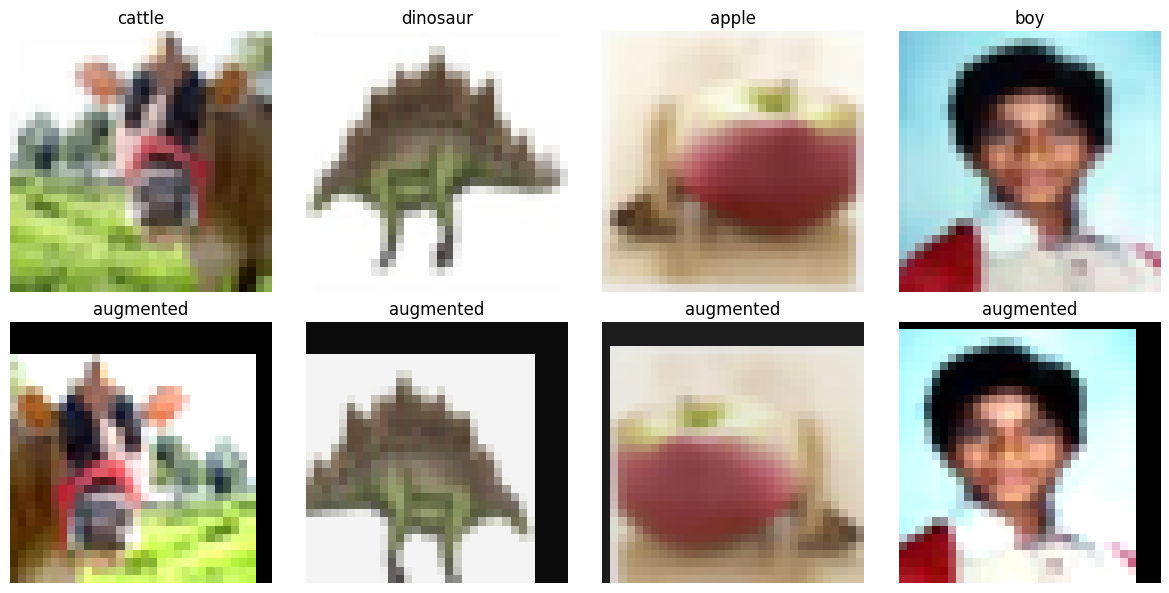


C1 SimpleCNN base
epoch=01 train_loss=4.6060 train_acc=0.0075 val_loss=4.5994 val_acc=0.0100
epoch=02 train_loss=4.5623 train_acc=0.0275 val_loss=4.6139 val_acc=0.0100

C2 SimpleCNN aug
epoch=01 train_loss=4.6107 train_acc=0.0175 val_loss=4.5904 val_acc=0.0100
epoch=02 train_loss=4.5663 train_acc=0.0275 val_loss=4.6022 val_acc=0.0100

C3 ResNet18 head-only
epoch=01 train_loss=4.9716 train_acc=0.0350 val_loss=4.6792 val_acc=0.0300
epoch=02 train_loss=4.2485 train_acc=0.0725 val_loss=4.4770 val_acc=0.0600

C4 ResNet18 layer4+fc
epoch=01 train_loss=4.6229 train_acc=0.0450 val_loss=4.1408 val_acc=0.1400
epoch=02 train_loss=2.8261 train_acc=0.4825 val_loss=3.7043 val_acc=0.1900


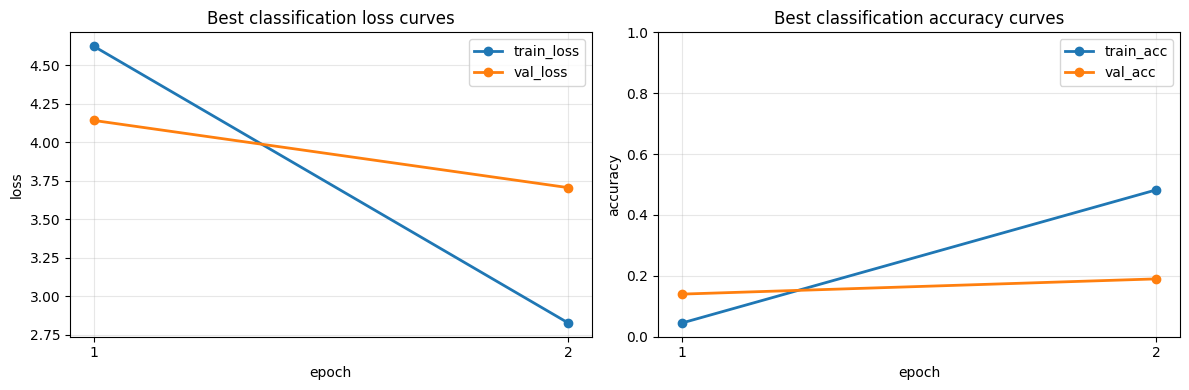

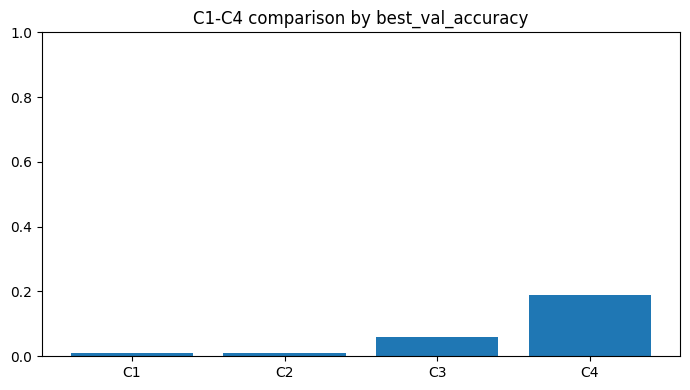

dataset part B: Pascal VOC segmentation
examples: 4
image.size: (334, 500)
x.shape: (3, 778, 520)
mask.shape: (500, 334)


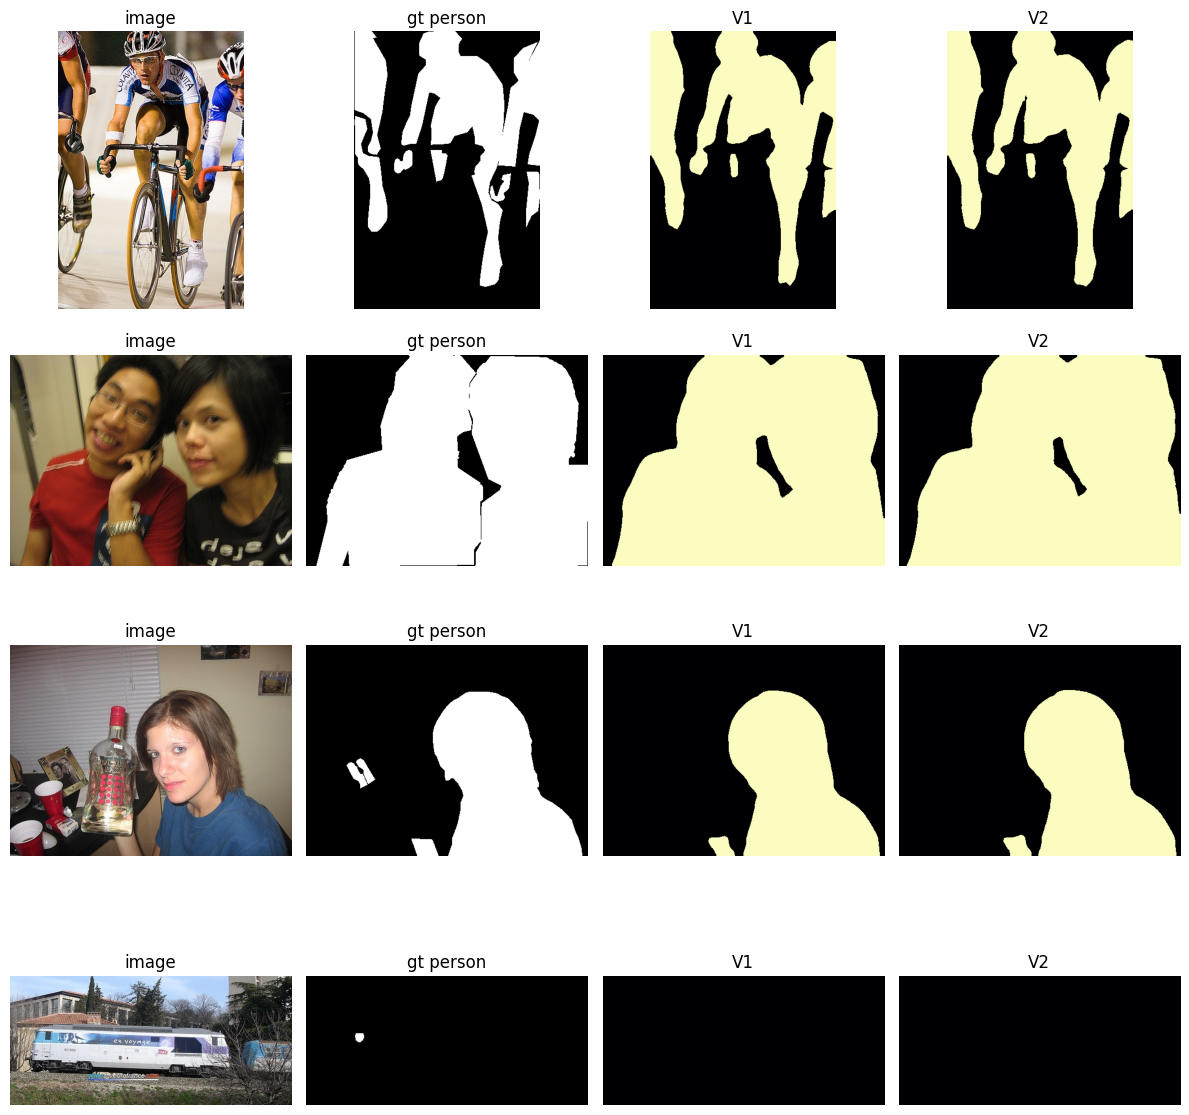

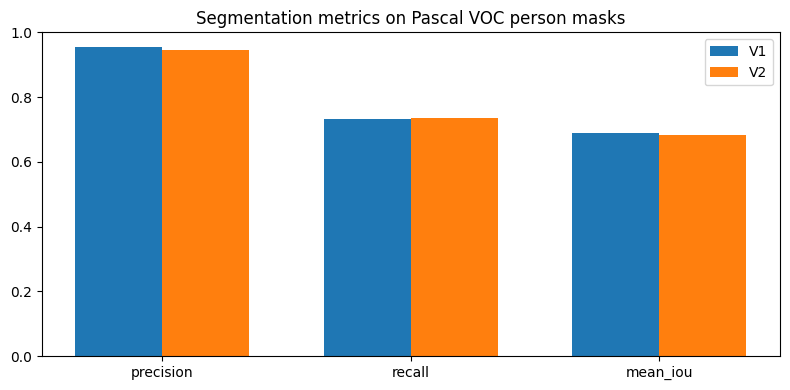


Saved files:
- artifacts\runs.csv
- artifacts\best_classifier.pt
- artifacts\best_classifier_config.json
- artifacts\summary.json
- artifacts\figures\augmentations_preview.png
- artifacts\figures\classification_curves_best.png
- artifacts\figures\classification_compare.png
- artifacts\figures\segmentation_examples.png
- artifacts\figures\segmentation_metrics.png


In [3]:
from __future__ import annotations

import copy
import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, models, transforms

SEED = 42
FAST_MODE = True
DATA_ROOT = Path('data')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
RUNS_PATH = ARTIFACTS_DIR / 'runs.csv'
BEST_MODEL_PATH = ARTIFACTS_DIR / 'best_classifier.pt'
BEST_CONFIG_PATH = ARTIFACTS_DIR / 'best_classifier_config.json'
SUMMARY_PATH = ARTIFACTS_DIR / 'summary.json'

for path in [DATA_ROOT, ARTIFACTS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Python:', sys.version.split()[0])
print('torch / torchvision:', torch.__version__)
print('device:', device)
print('seed:', SEED)
print('fast_mode:', FAST_MODE)

CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
PERSON_CLASS_INDEX = VOC_CLASSES.index('person')

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

aug_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

resnet_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, target = self.subset[idx]
        return self.transform(image), target

class VOCSegmentationBinaryDataset(Dataset):
    def __init__(self, subset, image_transform, class_index):
        self.subset = subset
        self.image_transform = image_transform
        self.class_index = class_index

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, mask = self.subset[idx]
        image_tensor = self.image_transform(image)
        mask_array = np.array(mask)
        binary_mask = torch.as_tensor(mask_array == self.class_index, dtype=torch.bool)
        return image, image_tensor, binary_mask

def denormalize(img, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (img.cpu() * std_t + mean_t).clamp(0, 1)

def save_and_show(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def describe_transform(transform):
    if hasattr(transform, 'transforms'):
        return [describe_transform(item) for item in transform.transforms]
    name = transform.__class__.__name__
    fields = {}
    for key, value in vars(transform).items():
        if key.startswith('_'):
            continue
        if isinstance(value, (str, int, float, bool, type(None))):
            fields[key] = value
        elif isinstance(value, (tuple, list)):
            fields[key] = list(value)
    return {'name': name, 'params': fields}

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)
    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)
    return total_loss / total_samples, total_correct / total_samples

def fit_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = None
    best_val_acc = -1.0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
        print(
            f'epoch={epoch:02d} train_loss={train_loss:.4f} train_acc={train_acc:.4f} '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )
    model.load_state_dict(best_state)
    return history, best_val_acc

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_resnet18(num_classes, finetune=False):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    if finetune:
        for param in model.layer4.parameters():
            param.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

def binary_metrics(pred_mask, true_mask):
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()
    tp = torch.logical_and(pred_mask, true_mask).sum().item()
    fp = torch.logical_and(pred_mask, ~true_mask).sum().item()
    fn = torch.logical_and(~pred_mask, true_mask).sum().item()
    union = torch.logical_or(pred_mask, true_mask).sum().item()
    precision = tp / (tp + fp) if tp + fp else 1.0
    recall = tp / (tp + fn) if tp + fn else 1.0
    mean_iou = tp / union if union else 1.0
    return precision, recall, mean_iou

train_dataset_raw = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True)
test_dataset_raw = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True)
class_names = train_dataset_raw.classes
num_classes = len(class_names)

if FAST_MODE:
    train_limit = 500
    test_limit = 150
    epochs_map = {'C1': 2, 'C2': 2, 'C3': 2, 'C4': 2}
else:
    train_limit = len(train_dataset_raw)
    test_limit = len(test_dataset_raw)
    epochs_map = {'C1': 8, 'C2': 8, 'C3': 4, 'C4': 4}

train_subset_raw = Subset(train_dataset_raw, list(range(train_limit)))
test_subset_raw = Subset(test_dataset_raw, list(range(test_limit)))
val_size = int(len(train_subset_raw) * 0.2)
train_size = len(train_subset_raw) - val_size
generator = torch.Generator().manual_seed(SEED)
train_base_raw, val_raw = random_split(train_subset_raw, [train_size, val_size], generator=generator)

train_base = TransformDataset(train_base_raw, base_transform)
train_aug = TransformDataset(train_base_raw, aug_transform)
val_base = TransformDataset(val_raw, base_transform)
test_base = TransformDataset(test_subset_raw, base_transform)
train_resnet = TransformDataset(train_base_raw, resnet_train_transform)
val_resnet = TransformDataset(val_raw, resnet_eval_transform)
test_resnet = TransformDataset(test_subset_raw, resnet_eval_transform)

batch_size = 64 if device.type == 'cuda' else 32
train_loader_base = DataLoader(train_base, batch_size=batch_size, shuffle=True, num_workers=0)
train_loader_aug = DataLoader(train_aug, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_base = DataLoader(val_base, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_base = DataLoader(test_base, batch_size=batch_size, shuffle=False, num_workers=0)
train_loader_resnet = DataLoader(train_resnet, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_resnet = DataLoader(val_resnet, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_resnet = DataLoader(test_resnet, batch_size=batch_size, shuffle=False, num_workers=0)

x_batch, y_batch = next(iter(train_loader_base))
print('dataset part A: CIFAR100')
print('train/val/test:', len(train_base), len(val_base), len(test_base))
print('x.shape:', tuple(x_batch.shape))
print('y.shape:', tuple(y_batch.shape))

preview_images = []
preview_labels = []
for idx in range(4):
    image, label = train_dataset_raw[idx]
    preview_images.append(image)
    preview_labels.append(label)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(preview_images[i])
    axes[0, i].set_title(class_names[preview_labels[i]])
    axes[0, i].axis('off')
    aug_img = aug_transform(preview_images[i])
    axes[1, i].imshow(denormalize(aug_img, CIFAR100_MEAN, CIFAR100_STD).permute(1, 2, 0).numpy())
    axes[1, i].set_title('augmented')
    axes[1, i].axis('off')
plt.tight_layout()
save_and_show(fig, FIGURES_DIR / 'augmentations_preview.png')

criterion = nn.CrossEntropyLoss()
experiments = [
    {
        'experiment_id': 'C1',
        'task': 'classification',
        'dataset': 'CIFAR100',
        'model_summary': 'SimpleCNN base',
        'builder': lambda: SimpleCNN(num_classes),
        'train_loader': train_loader_base,
        'val_loader': val_loader_base,
        'test_loader': test_loader_base,
        'optimizer_name': 'Adam',
        'lr': 1e-3,
        'notes': 'Simple CNN without augmentations.',
    },
    {
        'experiment_id': 'C2',
        'task': 'classification',
        'dataset': 'CIFAR100',
        'model_summary': 'SimpleCNN aug',
        'builder': lambda: SimpleCNN(num_classes),
        'train_loader': train_loader_aug,
        'val_loader': val_loader_base,
        'test_loader': test_loader_base,
        'optimizer_name': 'Adam',
        'lr': 1e-3,
        'notes': 'Simple CNN with light augmentations.',
    },
    {
        'experiment_id': 'C3',
        'task': 'classification',
        'dataset': 'CIFAR100',
        'model_summary': 'ResNet18 head-only',
        'builder': lambda: build_resnet18(num_classes, finetune=False),
        'train_loader': train_loader_resnet,
        'val_loader': val_loader_resnet,
        'test_loader': test_loader_resnet,
        'optimizer_name': 'Adam',
        'lr': 1e-3,
        'notes': 'Pretrained ResNet18, only fc is trainable.',
    },
    {
        'experiment_id': 'C4',
        'task': 'classification',
        'dataset': 'CIFAR100',
        'model_summary': 'ResNet18 layer4+fc',
        'builder': lambda: build_resnet18(num_classes, finetune=True),
        'train_loader': train_loader_resnet,
        'val_loader': val_loader_resnet,
        'test_loader': test_loader_resnet,
        'optimizer_name': 'AdamW',
        'lr': 3e-4,
        'notes': 'Pretrained ResNet18, layer4 and fc are trainable.',
    },
]

runs = []
best_bundle = None

for exp in experiments:
    print('\n' + '=' * 80)
    print(exp['experiment_id'], exp['model_summary'])
    model = exp['builder']().to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    if exp['optimizer_name'] == 'AdamW':
        optimizer = optim.AdamW(params, lr=exp['lr'], weight_decay=1e-4)
    else:
        optimizer = optim.Adam(params, lr=exp['lr'])
    history, best_val_acc = fit_model(
        model,
        exp['train_loader'],
        exp['val_loader'],
        optimizer,
        criterion,
        epochs_map[exp['experiment_id']],
    )
    runs.append({
        'experiment_id': exp['experiment_id'],
        'task': exp['task'],
        'dataset': exp['dataset'],
        'seed': SEED,
        'model_summary': exp['model_summary'],
        'optimizer': exp['optimizer_name'],
        'lr': exp['lr'],
        'epochs_trained': epochs_map[exp['experiment_id']],
        'best_val_accuracy': round(float(best_val_acc), 4),
        'test_accuracy': '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': exp['notes'],
    })
    if best_bundle is None or best_val_acc > best_bundle['best_val_accuracy']:
        best_bundle = {
            'experiment_id': exp['experiment_id'],
            'model': model,
            'history': history,
            'best_val_accuracy': best_val_acc,
            'test_loader': exp['test_loader'],
            'config': {
                'task': 'classification',
                'selected_experiment': exp['experiment_id'],
                'dataset': {
                    'name': 'CIFAR100',
                    'source': 'torchvision.datasets.CIFAR100',
                    'data_root': str(DATA_ROOT),
                    'num_classes': num_classes,
                    'class_names_preview': class_names[:10],
                },
                'split': {
                    'strategy': 'official train/test + reproducible random_split(train, 80/20)',
                    'seed': SEED,
                    'train_size': len(exp['train_loader'].dataset),
                    'val_size': len(exp['val_loader'].dataset),
                    'test_size': len(exp['test_loader'].dataset),
                    'fast_mode_train_limit': train_limit,
                    'fast_mode_test_limit': test_limit,
                },
                'model': {
                    'architecture': exp['model_summary'],
                    'family': 'ResNet18' if exp['experiment_id'] in {'C3', 'C4'} else 'SimpleCNN',
                    'pretrained': exp['experiment_id'] in {'C3', 'C4'},
                    'trainable_parts': 'layer4 + fc' if exp['experiment_id'] == 'C4' else ('fc only' if exp['experiment_id'] == 'C3' else 'all parameters'),
                },
                'transforms': {
                    'base_transform': describe_transform(base_transform),
                    'augmentation_transform': describe_transform(aug_transform),
                    'resnet_train_transform': describe_transform(resnet_train_transform),
                    'resnet_eval_transform': describe_transform(resnet_eval_transform),
                },
                'training': {
                    'criterion': 'CrossEntropyLoss',
                    'optimizer': exp['optimizer_name'],
                    'lr': exp['lr'],
                    'weight_decay': 1e-4 if exp['optimizer_name'] == 'AdamW' else 0.0,
                    'batch_size': batch_size,
                    'epochs_trained': epochs_map[exp['experiment_id']],
                    'device': str(device),
                    'fast_mode': FAST_MODE,
                },
                'seed': SEED,
                'selection_metric': 'best_val_accuracy',
                'notes': exp['notes'],
            },
        }

best_test_loss, best_test_acc = evaluate(best_bundle['model'], best_bundle['test_loader'], criterion)
best_bundle['config']['results'] = {
    'best_val_accuracy': round(float(best_bundle['best_val_accuracy']), 4),
    'test_loss': round(float(best_test_loss), 4),
    'test_accuracy': round(float(best_test_acc), 4),
}
for run in runs:
    if run['experiment_id'] == best_bundle['experiment_id']:
        run['test_accuracy'] = round(float(best_test_acc), 4)

torch.save(best_bundle['model'].state_dict(), BEST_MODEL_PATH)
with BEST_CONFIG_PATH.open('w', encoding='utf-8') as f:
    json.dump(best_bundle['config'], f, ensure_ascii=False, indent=2)

history = best_bundle['history']
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], marker='o', linewidth=2, markersize=6, label='train_loss')
axes[0].plot(epochs, history['val_loss'], marker='o', linewidth=2, markersize=6, label='val_loss')
axes[0].set_title('Best classification loss curves')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_xticks(epochs)
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(epochs, history['train_acc'], marker='o', linewidth=2, markersize=6, label='train_acc')
axes[1].plot(epochs, history['val_acc'], marker='o', linewidth=2, markersize=6, label='val_acc')
axes[1].set_title('Best classification accuracy curves')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
save_and_show(fig, FIGURES_DIR / 'classification_curves_best.png')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([run['experiment_id'] for run in runs if run['task'] == 'classification'], [run['best_val_accuracy'] for run in runs if run['task'] == 'classification'])
ax.set_title('C1-C4 comparison by best_val_accuracy')
ax.set_ylim(0, 1)
plt.tight_layout()
save_and_show(fig, FIGURES_DIR / 'classification_compare.png')

voc_raw = datasets.VOCSegmentation(root=DATA_ROOT, year='2012', image_set='val', download=True)
positive_indices = []
limit = 4 if FAST_MODE else 20
for idx in range(len(voc_raw)):
    _, mask = voc_raw[idx]
    if (np.array(mask) == PERSON_CLASS_INDEX).any():
        positive_indices.append(idx)
        if len(positive_indices) >= limit:
            break

seg_weights = models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
seg_transform = seg_weights.transforms()
voc_binary = VOCSegmentationBinaryDataset(Subset(voc_raw, positive_indices), seg_transform, PERSON_CLASS_INDEX)

print('dataset part B: Pascal VOC segmentation')
print('examples:', len(voc_binary))
if len(voc_binary) == 0:
    raise RuntimeError('No Pascal VOC validation images with class person were found for the current fast_mode setup.')
raw_image, x_seg, y_seg = voc_binary[0]
print('image.size:', raw_image.size)
print('x.shape:', tuple(x_seg.shape))
print('mask.shape:', tuple(y_seg.shape))

seg_model = models.segmentation.deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()

@torch.no_grad()
def predict_mask(image_tensor, mode, target_shape=None):
    logits = seg_model(image_tensor.unsqueeze(0).to(device))['out'].cpu()
    if target_shape is not None:
        logits = F.interpolate(logits, size=target_shape, mode='bilinear', align_corners=False)
    logits = logits[0]
    probs = torch.softmax(logits, dim=0)
    if mode == 'V1':
        # V1 postprocessing: argmax over all VOC classes, then keep only person pixels.
        return logits.argmax(dim=0) == PERSON_CLASS_INDEX
    # V2 postprocessing: threshold the softmax probability for the person class.
    return probs[PERSON_CLASS_INDEX] > 0.35

seg_rows = []
metric_names = ['precision', 'recall', 'mean_iou']
metric_summary = {}
for mode in ['V1', 'V2']:
    all_metrics = []
    for idx in range(len(voc_binary)):
        _, image_tensor, true_mask = voc_binary[idx]
        pred_mask = predict_mask(image_tensor, mode, target_shape=true_mask.shape)
        precision, recall, mean_iou = binary_metrics(pred_mask, true_mask)
        all_metrics.append((precision, recall, mean_iou))
    precision = round(float(np.mean([m[0] for m in all_metrics])), 4)
    recall = round(float(np.mean([m[1] for m in all_metrics])), 4)
    mean_iou = round(float(np.mean([m[2] for m in all_metrics])), 4)
    metric_summary[mode] = {'precision': precision, 'recall': recall, 'mean_iou': mean_iou}
    seg_rows.append({
        'experiment_id': mode,
        'task': 'segmentation',
        'dataset': 'Pascal VOC 2012',
        'seed': SEED,
        'model_summary': 'DeepLabV3_ResNet50 pretrained',
        'optimizer': '',
        'lr': '',
        'epochs_trained': 0,
        'best_val_accuracy': '',
        'test_accuracy': '',
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'notes': 'foreground = person',
    })

rows = max(1, min(4, len(voc_binary)))
fig, axes = plt.subplots(rows, 4, figsize=(12, 3 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
for row in range(min(rows, len(voc_binary))):
    raw_img, image_tensor, true_mask = voc_binary[row]
    pred_v1 = predict_mask(image_tensor, 'V1', target_shape=true_mask.shape)
    pred_v2 = predict_mask(image_tensor, 'V2', target_shape=true_mask.shape)
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title('image')
    axes[row, 1].imshow(true_mask.cpu().numpy(), cmap='gray')
    axes[row, 1].set_title('gt person')
    axes[row, 2].imshow(pred_v1.cpu().numpy(), cmap='magma')
    axes[row, 2].set_title('V1')
    axes[row, 3].imshow(pred_v2.cpu().numpy(), cmap='magma')
    axes[row, 3].set_title('V2')
    for col in range(4):
        axes[row, col].axis('off')
plt.tight_layout()
save_and_show(fig, FIGURES_DIR / 'segmentation_examples.png')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metric_names))
width = 0.35
ax.bar(x - width / 2, [metric_summary['V1'][name] for name in metric_names], width=width, label='V1')
ax.bar(x + width / 2, [metric_summary['V2'][name] for name in metric_names], width=width, label='V2')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.set_title('Segmentation metrics on Pascal VOC person masks')
ax.legend()
plt.tight_layout()
save_and_show(fig, FIGURES_DIR / 'segmentation_metrics.png')

runs.extend(seg_rows)

with RUNS_PATH.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(
        f,
        fieldnames=['experiment_id', 'task', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'epochs_trained', 'best_val_accuracy', 'test_accuracy', 'precision', 'recall', 'mean_iou', 'notes'],
    )
    writer.writeheader()
    writer.writerows(runs)

summary = {
    'dataset_part_a': 'CIFAR100',
    'dataset_part_b': 'Pascal VOC 2012',
    'track_part_b': 'segmentation',
    'seed': SEED,
    'device': str(device),
    'fast_mode': FAST_MODE,
    'best_experiment': best_bundle['experiment_id'],
    'best_val_accuracy': round(float(best_bundle['best_val_accuracy']), 4),
    'test_accuracy': round(float(best_test_acc), 4),
    'v1_postprocessing': 'argmax over VOC classes, then keep person pixels',
    'v2_postprocessing': 'softmax(person) > 0.35',
    'segmentation_v1': metric_summary['V1'],
    'segmentation_v2': metric_summary['V2'],
}
with SUMMARY_PATH.open('w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('\nSaved files:')
for path in [
    RUNS_PATH,
    BEST_MODEL_PATH,
    BEST_CONFIG_PATH,
    SUMMARY_PATH,
    FIGURES_DIR / 'augmentations_preview.png',
    FIGURES_DIR / 'classification_curves_best.png',
    FIGURES_DIR / 'classification_compare.png',
    FIGURES_DIR / 'segmentation_examples.png',
    FIGURES_DIR / 'segmentation_metrics.png',
]:
    print('-', path)


